# Bathymetry and Boundaries for AMR-Wind from FVCOM

In [1]:
# Load modules.

import numpy as np
import pandas as pd
import sys, math  
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.autolayout'] = True
import os, glob, shutil
import subprocess
import time
import netCDF4 as nc
import xarray as xr
import scipy as sc
import inflowPrepMMC as mmc





## Load FVCOM Data

In [2]:
# Rather than load all the FVCOM data, which is slow, Will loaded and then saved some of the data in 
# numpy format.  That's what gets loaded here.  Still one netcdf file gets loaded just to get some basic
# location information.

basepath = '/projects/hindcastra/Tidal/datasets/high_resolution_tidal_hindcast/WA_puget_sound/v1.0.0/00_raw/Puget_Sound_corrected/02012015/'
savepath = '/projects/hindcastra/LES/PugetSound/'
ds = xr.open_dataset(basepath+'psm_0001.nc',decode_times=False)
latlon = np.array([[5.375e6,5.3815e6],[514000,521000]])
latlontrue = np.where(np.array(ds.yc.values > np.min(latlon[0])) \
                    & np.array(ds.yc.values < np.max(latlon[0])) \
                    & np.array(ds.xc.values > np.min(latlon[1])) \
                    & np.array(ds.xc.values < np.max(latlon[1])))[0]

#time = np.array(ds.time.values); np.save(savepath+'PS_time.npy',time);
#x = np.array(ds.xc[latlontrue].values); np.save(savepath+'PS_x.npy',x);
#y = np.array(ds.yc[latlontrue].values); np.save(savepath+'PS_y.npy',y);
#h = np.array(ds.h_center[latlontrue].values); np.save(savepath+'PS_h.npy',h);
#nv = np.array(ds.nv[:,latlontrue].values) - 1; np.save(savepath+'PS_nv.npy',nv);
#siglay = np.array(ds.siglay_center[:,latlontrue].values); np.save(savepath+'PS_siglay.npy',siglay);
#u = np.zeros((ds.u.shape[0],ds.u.shape[1],len(latlontrue)))
#v = np.zeros((ds.u.shape[0],ds.u.shape[1],len(latlontrue)))
#zeta = np.zeros((ds.zeta.shape[0],ds.zeta.shape[1]))
#for t in range(u.shape[0]):
#    zeta[t,:] = ds.zeta[t,:].values
#    for z in range(u.shape[1]):
#        u[t,z,:] = ds.u[t,z,latlontrue].values
#        v[t,z,:] = ds.v[t,z,latlontrue].values
#np.save(savepath+'PS_u.npy',u);
#np.save(savepath+'PS_v.npy',v);
#np.save(savepath+'PS_zeta.npy',zeta);

time = np.load(savepath+'PS_time.npy')
x = np.load(savepath+'PS_x.npy');             # east direction
y = np.load(savepath+'PS_y.npy');             # north direction
h = np.load(savepath+'PS_h.npy');             # depth
nv = np.load(savepath+'PS_nv.npy');
siglay = np.load(savepath+'PS_siglay.npy');
u = np.load(savepath+'PS_u.npy');             # east velocity
v = np.load(savepath+'PS_v.npy');             # north velocity
zeta_node = np.load(savepath+'PS_zeta.npy');
zeta = np.zeros((len(time),len(x)))
for t in range(zeta.shape[0]):
    zeta[t,:] = np.mean(zeta_node[t,nv])



    

/home/mchurchf/.conda-envs/condaEnv.a/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [3]:
# Find the indices of points that are within 100 m of the point of interest.

deploymentLocation = [5.17500e5,5.3785e6]
distTol = 100.0
deploymentTol = 40.0

# point of interest
inpoint = [518000,5.3765e6]

# compute distance from a plane passing through the point of interest with normal "invec"
invec = [0,1]
dist = np.abs(np.transpose([x - inpoint[0],y - inpoint[1]]) @ invec)

# array of true/false if index is within 100 m.  Later this becomes grid points surrounding the "inlet" if flow is from south to north.
iin = np.array(dist < distTol)

# find roughly the location of deployment
ifast = np.where(((x - deploymentLocation[0])**2 + (y - deploymentLocation[1])**2)**0.5 < deploymentTol)[0][0] 

print('index of deployment location:',ifast)





index of deployment location: 3697


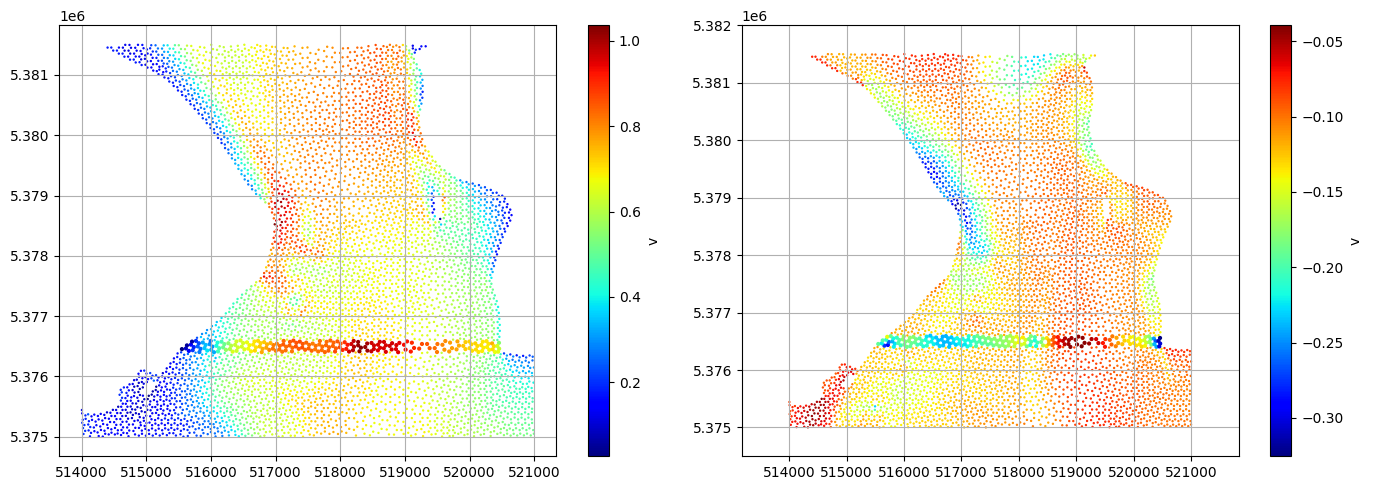

In [4]:
# Plot some of the data.  Choose the field, the time, and the sigma level.

field0 = v
t0 = 0
sig0 = 1

field1 = v
t1 = 10
sig1 = 1

if len(field0.shape) == 3:
    color0 = field0[t0,sig0,:]
    colorin0 = field0[t0,sig0,iin]
elif len(field0.shape) == 2:
    if field0.shape[0] == time0.shape[0]:
        color0 = field0[t0,:]
        colorin0 = field0[t0,iin]
    else:
        color0 = field[sig0,:]
        colorin0 = field[sig0,iin]
elif len(field.shape) == 1:
    color0 = field0
    colorin0 = field0[iin]

if len(field1.shape) == 3:
    color1 = field1[t1,sig1,:]
    colorin1 = field1[t1,sig1,iin]
elif len(field1.shape) == 2:
    if field1.shape[0] == time1.shape[0]:
        color1 = field1[t1,:]
        colorin1 = field1[t1,iin]
    else:
        color1 = field[sig1,:]
        colorin1 = field[sig1,iin]
elif len(field.shape) == 1:
    color1 = field1
    colorin1 = field1[iin]



fig,axs = plt.subplots(1,2,figsize=(14,5))

scat0 = axs[0].scatter(x,y,c=color0,cmap='jet',s=0.5)
scat0 = axs[0].scatter(x[iin],y[iin],c=colorin0,cmap='jet',s=4)
plt.axis('equal')
plt.colorbar(scat0,label='v')

scat1 = axs[1].scatter(x,y,c=color1,cmap='jet',s=0.5)
scat1 = axs[1].scatter(x[iin],y[iin],c=colorin1,cmap='jet',s=4)
plt.axis('equal')
plt.colorbar(scat1,label='v')

plt.show()





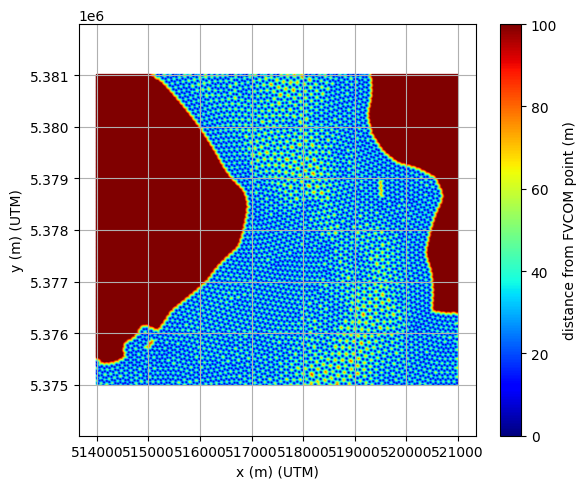

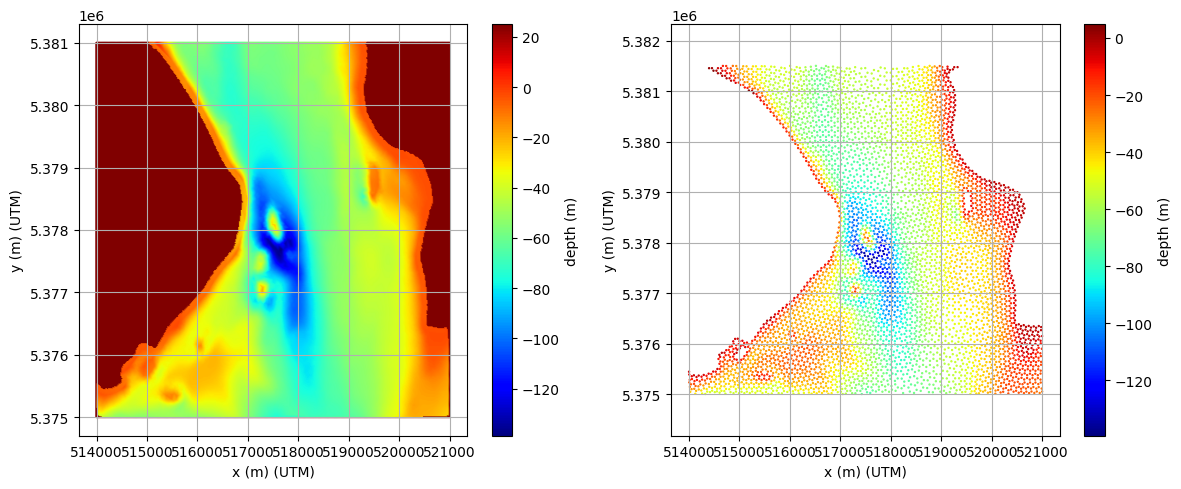

In [5]:
# Get the bathymmetry data.  

# The bathymmetry data is stored in FVCOM's unstructured grid, but we need to get it on a structured grid because the AMR-Wind
# terrain data is structured.

# Define the extents and resolution of the structured data plane.  x,y coordinates are in UTM.  Land is not represented in the FVCOM
# data, so we also need to give a land height.  We will use interpolation to go from the unstructured to structured grid and the
# structured grid of bathymmetry height will include land, so we need to give a land height.  The interpolation by default tries to 
# interpolate the land regions from surrounding known bathymetry depths, and won't return higher than water level values.  So, also
# have to find distance of every structured point from an unstructured point and if that distance is greater than some value (distTol),
# treat it as land and assign it the land height value.

nx = 400
ny = 400
xMin = 514000
xMax = 521000
yMin = 5.375E6
yMax = 5.381E6

landHeight = 25.0
distTol = 100.0




# Form the structured arrays.
xStruct = np.tile(np.linspace(xMin,xMax,nx),ny)
yStruct = np.repeat(np.linspace(yMin,yMax,ny),nx)
hStruct = np.zeros((nx*ny))
distStruct = np.zeros((nx*ny))

# Compute distance of each structured point to nearest unstructured point.
for i in range(nx*ny):
    d = np.sqrt(np.square(xStruct[i] - x) + np.square(yStruct[i] - y))
    distStruct[i] = np.min(d)

# Use scipy's griddata interpolator to interpolate from unstructured depths to structured.
hStruct = sc.interpolate.griddata((x,y),-h,(xStruct,yStruct),method='linear',fill_value=landHeight)


# If a structured point is far enough from an unstructured point, treat it as land.
for i in range(nx*ny):
    if (distStruct[i] > distTol):
        hStruct[i] = landHeight


# Plot the distance values as a check and a way to determine what to set distTol to.
fig,axs = plt.subplots(1,1,figsize=(6,5))
scat = axs.scatter(xStruct,yStruct,c=distStruct,cmap='jet',vmin=0,vmax=100,s=0.5)
plt.axis('equal')
axs.set_xlabel('x (m) (UTM)')
axs.set_ylabel('y (m) (UTM)')
plt.colorbar(scat,label='distance from FVCOM point (m)')
plt.show()



# Plot the structured and unstructed depth data as a check.
fig,axs = plt.subplots(1,2,figsize=(12,5))
scat = axs[0].scatter(xStruct,yStruct,c=hStruct,cmap='jet',s=0.5)
plt.axis('equal')
axs[0].set_xlabel('x (m) (UTM)')
axs[0].set_ylabel('y (m) (UTM)')
plt.colorbar(scat,label='depth (m)')

scat = axs[1].scatter(x,y,c=-h,cmap='jet',s=0.5)
plt.axis('equal')
plt.colorbar(scat,label='depth (m)')
axs[1].set_xlabel('x (m) (UTM)')
axs[1].set_ylabel('y (m) (UTM)')

plt.show()





In [6]:
# Write the bathymmetry and land height data as an AMR-Wind terrain file.

# Odd interpolation artifacts were happening right at the boundary of structured interpolated data, so for now let's say that the 
# AMR-Wind grid will fit inside the terrain data we have by some buffer distance (buffer).  In other words, if we drew the AMR-Wind
# grid footprint on top of the terrain data, it would be a rectangle inside the terrain data rectangle with an offset of 'buffer'.  

# We also set 0,0 as the location down near the southwest (lower left) corner so that we don't have to make an AMR-Wind grid that
# follows UTM coordinates, but really there is no reason we have to do this.  If you want AMR-Wind's grid to be in UTM coordinates, 
# then just get rid of the '-xMin-buffer' and '-yMin-buffer' You see immediate below.

# Write the AMR-Wind terrain data using Matt's writer function that's in his inflowPrepMMC module.

buffer = 250.0
bathymmetry = mmc.inflowPrepMMC()
bathymmetry.writeAMRWindTerrain(np.transpose(np.reshape(xStruct-xMin-buffer,(nx,ny))),
                                np.transpose(np.reshape(yStruct-yMin-buffer,(nx,ny))),
                                np.transpose(np.reshape(hStruct,(nx,ny))))





Writing AMR-Wind immersed boundary terrain file...


In [37]:
## Velocity plane for inlet or outlet

# number of points horizontally and vertically in interpolation plane along with times
nx = 400
nz = 100
nt = ds['time'].shape[0]

# Define the inlet plane variable array which can hold 4 variables.
inlet = np.zeros((nh,nv,nt,4))

# Define the plane geometry to interpolate to.  This is an x-z plane right
gridpointsXZ = np.zeros((nx*nz,3))
gridpointsXZ[:,0] = np.tile(np.linspace(515000,521000,nx),nz)
gridpointsXZ[:,1] = np.tile(np.linspace(inpoint[1],inpoint[1],nx),nz)
gridpointsXZ[:,2] = np.repeat(np.linspace(-np.max(h),10.0,nz),nx)

# This is the subset of FVCOM data to interpolate from.  It is what is highlighted in the plot above.  The variable
# "siglay" is the depth.
xinterp = np.tile(x[iin],siglay.shape[0])
yinterp = np.tile(y[iin],siglay.shape[0])

bot = sc.interpolate.griddata((x[iin],y[iin]),-h[iin],gridpoints[:,0:2],method='linear')


for t in range(len(time)):
    zin = np.zeros((np.sum(iin),siglay.shape[0]))
    for z in range(zin.shape[1]):
        zin[:,z] = -h[iin]-(h[iin]+zeta[t,iin])*siglay[z,iin]
    zin = zin.flatten(order='F')
    top = sc.interpolate.griddata((x[iin],y[iin]),zeta[t,iin],gridpoints[:,0:2],method='linear')
    inlet[:,:,t,0] = (np.array(gridpointsXZ[:,2]>bot)*np.array(gridpoints[:,2]<top)*sc.interpolate.griddata((xinterp,yinterp,zin),u[t,:,iin].flatten(order='F'),gridpointsXZ,method='linear',fill_value=0)).reshape((nx,nz),order='F')
    inlet[:,:,t,1] = (np.array(gridpointsXZ[:,2]>bot)*np.array(gridpoints[:,2]<top)*sc.interpolate.griddata((xinterp,yinterp,zin),v[t,:,iin].flatten(order='F'),gridpointsXZ,method='linear',fill_value=0)).reshape((nx,nz),order='F')
    top = sc.interpolate.griddata((x[iin],y[iin]),zeta[t,iin],gridpoints[:,0:2],method='nearest')
    inlet[:,:,t,3] = np.array(gridpointsXZ[:,2]<top).reshape((nh,nv),order='F')



[nan nan nan ... nan nan nan]
[2.29498672 2.29498672 2.29498672 ... 2.29498672 2.29498672 2.29498672]
[[[[0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   ...
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]]

  [[0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   ...
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]]

  [[0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   ...
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]]

  ...

  [[0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   ...
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   ...
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   ...
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]]]


 [[[0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   ...
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]]

  [[0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   ...
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]
   [0. 0. 0. 1.]]

 

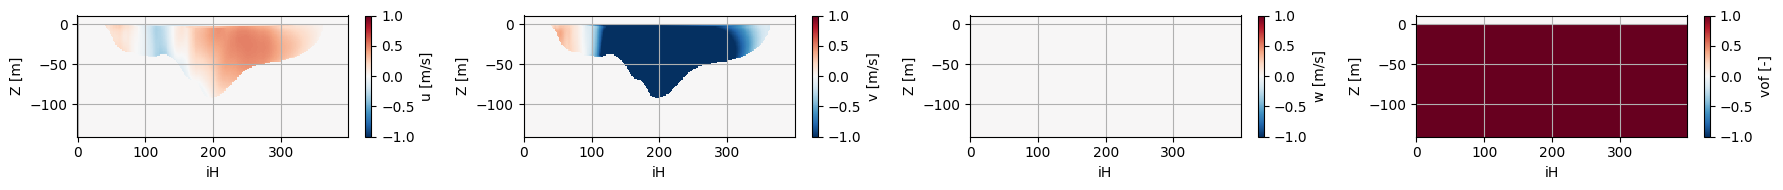

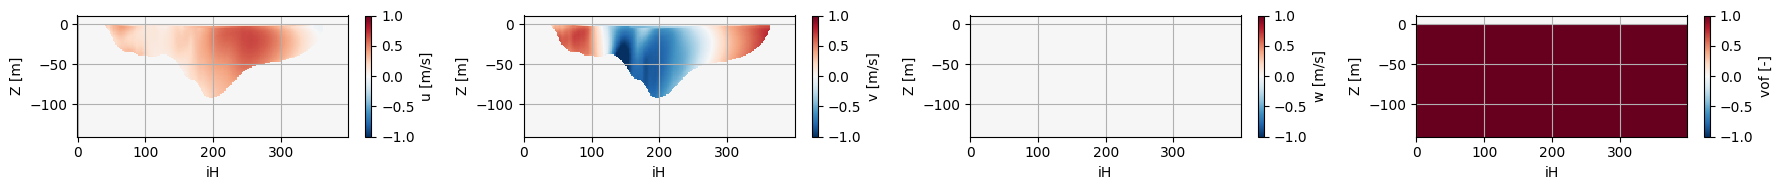

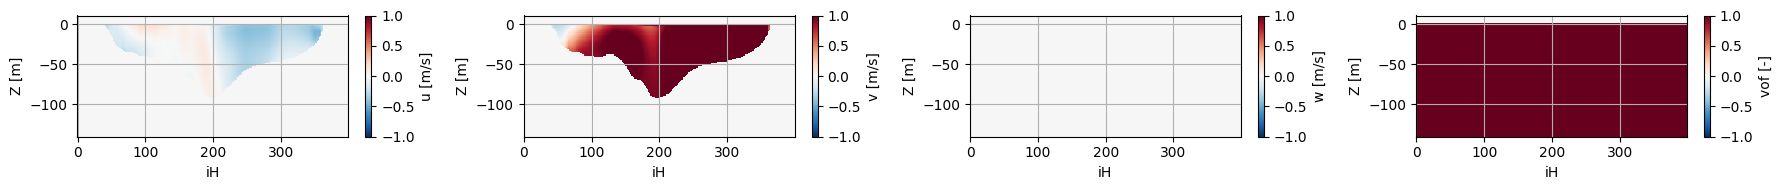

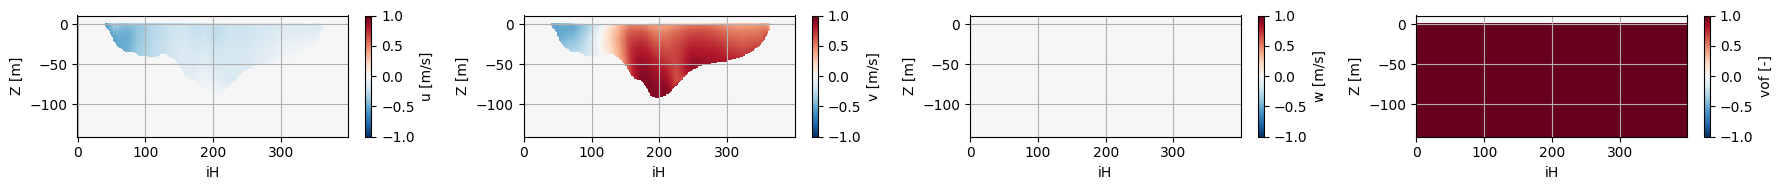

In [33]:
for t in [86,92,100,105]:
    fig,axs = plt.subplots(1,4,figsize=(18,2))
    for dir in range(4):
        im = axs[dir].pcolormesh(range(nh),np.linspace(-np.max(h),10.0,nv),np.transpose(inlet[:,:,t,dir]),vmin=-1,vmax=1,cmap='RdBu_r',shading='nearest')
        plt.colorbar(im,ax=axs[dir],label=['u [m/s]','v [m/s]','w [m/s]','vof [-]'][dir])
        axs[dir].set(xlabel='iH',ylabel='Z [m]')
    plt.show()

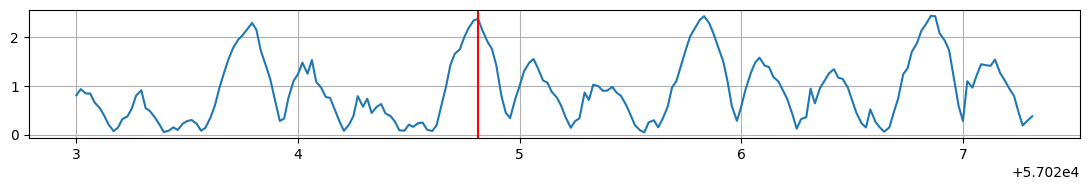

In [7]:
## Pick time step to use (

sig = 0
fig,axs = plt.subplots(1,1,figsize=(11,2))
axs.plot(time,(u[:,sig,ifast]**2+v[:,sig,ifast]**2)**0.5)
#axs.plot(time,np.mean(v[:,sig,iin],1))
for t in [87]:
    axs.axvline(time[t],c='r')
plt.show()

In [8]:
## Save netcdf file for selected time step (only 1 time since FVCOM dt is 30 minutes)

t = 87

if os.path.exists(savepath+'inlet.nc'): os.remove(savepath+'inlet.nc')
with nc.Dataset(savepath+'inlet.nc', 'w', format='NETCDF4') as inletnc:
    inletnc.description = 'Inlet Boundary'
    inletnc.createDimension('ncell',nh*nv)
    xnc = inletnc.createVariable('x','f4',('ncell',))
    ync = inletnc.createVariable('y','f4',('ncell',))
    znc = inletnc.createVariable('z','f4',('ncell',))
    unc = inletnc.createVariable('u','f4',('ncell',))
    vnc = inletnc.createVariable('v','f4',('ncell',))
    wnc = inletnc.createVariable('w','f4',('ncell',))
    vofnc = inletnc.createVariable('vof','f4',('ncell',))
    xnc.units = 'm'
    ync.units = 'm'
    znc.units = 'm'
    unc.units = 'm/s'
    vnc.units = 'm/s'
    wnc.units = 'm/s'
    vofnc.units = '-'
    xnc[:] = gridpoints[:,0]
    ync[:] = gridpoints[:,1]
    znc[:] = gridpoints[:,2]
    unc[:] = inlet[:,:,t,0].flatten(order='F')
    vnc[:] = inlet[:,:,t,1].flatten(order='F')
    wnc[:] = inlet[:,:,t,2].flatten(order='F')
    vofnc[:] = inlet[:,:,t,3].flatten(order='F')

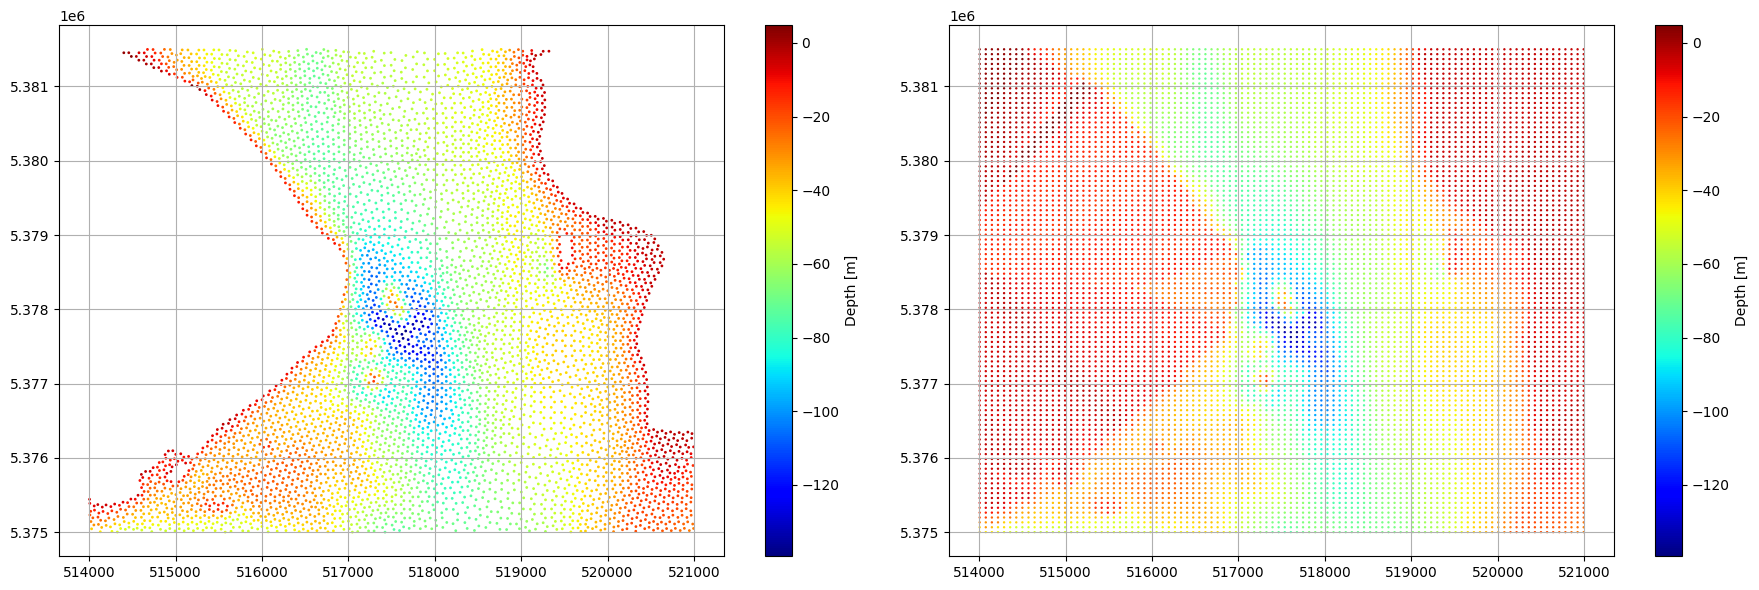

Text(0, 0.5, 'y (km)')

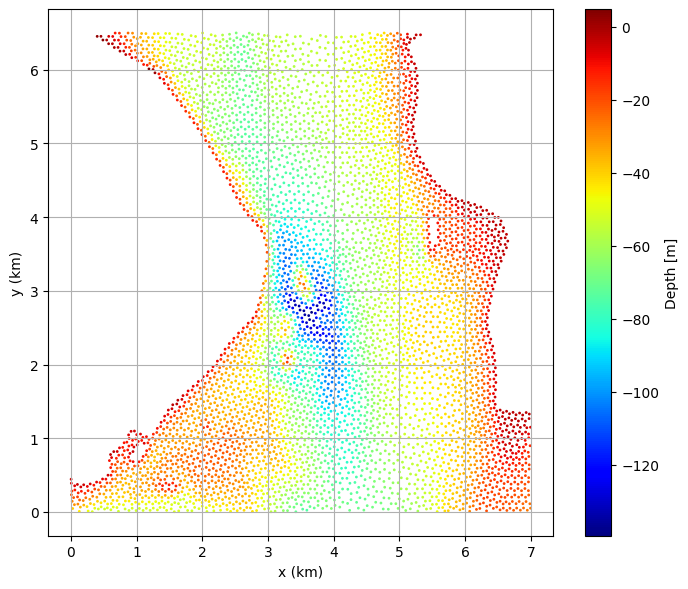

In [18]:
## Build channel file

nx = 100
ny = 100
xbath = np.linspace(np.min(x),np.max(x),nx)
ybath = np.linspace(np.min(y),np.max(y),ny)
zbath = np.zeros((nx*ny))

bath = np.zeros((2+nx+ny+nx*ny))
bath[0] = nx
bath[1] = ny
bath[2:2+nx] = xbath
bath[2+nx:2+nx+ny] = ybath

xyinterp = np.array([x,y]).T

for iy in range(ny):
    yy = ybath[iy]
    zrow = sc.interpolate.griddata(xyinterp,-h,np.array([xbath,np.ones(ny)*yy]).T,method='nearest')
    for ix in range(nx):
        xx = xbath[ix]
        zz = zrow[ix]
        zbath[ix*ny+iy] = zz
        bath[2+nx+ny+ix*ny+iy] = zz
np.savetxt(savepath+'channel.amrwind',bath,fmt='%.2f')

fig,axs = plt.subplots(1,2,figsize=(18,6))
im = axs[0].scatter(x,y,c=-h,cmap='jet',s=1)
plt.colorbar(im,ax=axs[0],label='Depth [m]')
im = axs[1].scatter(np.repeat(xbath,ny),np.tile(ybath,nx),c=zbath,cmap='jet',s=0.5)
plt.colorbar(im,ax=axs[1],label='Depth [m]')
plt.show()

plt.figure(1,figsize=(7,6))
im = plt.scatter((x/1000)-514,(y/1000)-5375,c=-h,cmap='jet',s=1)
plt.colorbar(im,label='Depth [m]')
plt.xlabel('x (km)')
plt.ylabel('y (km)')

## Old test case

In [ ]:
ex = np.loadtxt('/home/pwiley/AMRWind/amr-wind/test/test_files/terrain_box/terrain.amrwind')
nx = int(ex[0])
ny = int(ex[1])

x = ex[2:2+nx]
y = ex[2+nx:2+nx+ny]
z = ex[2+nx+ny:]

In [ ]:
fig = plt.figure(figsize=(6,6)); axs = plt.axes(projection ='3d');
for ix in range(nx):
    axs.scatter(x[ix]*np.ones(ny),y,z[ix*ny:ix*ny+ny])
axs.set(xlabel='x',ylabel='y')
plt.show()

In [ ]:
## Build channel file

xmin = 0.0
xmax = 100.0
ymin = -25.0
ymax = 25.0

zmin = -25.0

zside = -10.0
yslope = 10.0

nx = 64
ny = 32

x = np.linspace(xmin,xmax,nx)
y = np.linspace(ymin,ymax,ny)
z = np.zeros((nx*ny))

chan = np.zeros((2+nx+ny+nx*ny))
chan[0] = nx
chan[1] = ny
chan[2:2+nx] = x
chan[2+nx:2+nx+ny] = y

for iy in range(ny):
    yy = y[iy]
    for ix in range(nx):
        xx = x[ix]
        if np.abs(yy) > yslope:
            zz = (np.abs(yy)-yslope)/(ymax-yslope)*(zside-zmin) + zmin
        else:
            zz = zmin
        z[ix*ny+iy] = zz
        chan[2+nx+ny+ix*ny+iy] = zz

np.savetxt('/scratch/pwiley/Resource/AMRWind/ow_current_bathymetry/channel.amrwind',chan,fmt='%.2f')

fig = plt.figure(figsize=(6,6)); axs = plt.axes(projection ='3d');
for ix in range(nx):
    axs.scatter(x[ix],y*np.ones(ny),z[ix*ny:ix*ny+ny])
axs.set(xlabel='x',ylabel='y')
plt.show()